
# Regresión Logística: predicción del sistema operativo

**Objetivo:** construir un modelo de clasificación que permita predecir si un usuario utiliza:

- `0` → Windows
- `1` → Macintosh
- `2` → Linux

a partir de cuatro características obtenidas de Google Analytics:

1. Duración de la visita en segundos.
2. Cantidad de páginas vistas durante la sesión.
3. Cantidad de acciones del usuario.
4. Suma del valor de las acciones.

El modelo utilizado será **Regresión Logística Multiclase**.


In [1]:

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


Matplotlib is building the font cache; this may take a moment.


## 1. Cargar el conjunto de datos

In [2]:
# Cargar el archivo CSV
archivo = "usuarios_win_mac_lin.csv"
df = pd.read_csv(archivo)

print("Cantidad de filas y columnas:", df.shape)
display(df.head())


Cantidad de filas y columnas: (170, 5)


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [3]:

# Información general del conjunto de datos
print("Columnas:")
print(df.columns.tolist())

print("\nInformación:")
df.info()

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())


Columnas:
['duracion', 'paginas', 'acciones', 'valor', 'clase']

Información:
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB

Valores nulos por columna:


duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64


Estadísticas descriptivas:


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000



## 2. Preparar los datos

El modelo necesita separar:

- **Variables predictoras (X):** las cuatro características de la visita.
- **Variable objetivo (y):** el sistema operativo codificado como 0, 1 o 2.

> Si los nombres de las columnas del CSV son diferentes, modificá solamente la lista `columnas_X` y el nombre de `columna_y` en la celda siguiente.


In [4]:
# Variables predictoras y variable objetivo
columnas_X = ["duracion", "paginas", "acciones", "valor"]
columna_y = "clase"

X = df[columnas_X]
y = df[columna_y]

print("Variables predictoras:", columnas_X)
print("Variable objetivo:", columna_y)
print("\nDistribución de clases:")
display(y.value_counts().sort_index())


Variables predictoras: ['duracion', 'paginas', 'acciones', 'valor']
Variable objetivo: clase

Distribución de clases:


clase
0    86
1    40
2    44
Name: count, dtype: int64

## 3. Dividir los datos en entrenamiento y prueba

In [5]:

# 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)


Datos de entrenamiento: (136, 4)
Datos de prueba: (34, 4)



## 4. Estandarizar las variables

La estandarización permite que las variables tengan una escala comparable.

Se ajusta el `StandardScaler` únicamente con los datos de entrenamiento para evitar fuga de información.


In [6]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Estandarización realizada correctamente.")


Estandarización realizada correctamente.


## 5. Entrenar el modelo de Regresión Logística

In [7]:

# Regresión Logística Multiclase
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente.")
print("Clases aprendidas:", modelo.classes_)


Modelo entrenado correctamente.
Clases aprendidas: [0 1 2]


## 6. Realizar predicciones

In [8]:

y_pred = modelo.predict(X_test_scaled)

print("Primeras predicciones:")
print(y_pred[:10])

print("\nValores reales:")
print(y_test.to_numpy()[:10])


Primeras predicciones:
[2 0 2 2 2 2 0 2 2 0]

Valores reales:
[2 0 2 2 2 0 0 0 2 1]


## 7. Evaluar el modelo

In [9]:

accuracy = accuracy_score(y_test, y_pred)

print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Porcentaje de aciertos: {accuracy * 100:.2f}%")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Windows", "Macintosh", "Linux"],
    zero_division=0
))


Exactitud (Accuracy): 0.7059
Porcentaje de aciertos: 70.59%

Reporte de clasificación:
              precision    recall  f1-score   support

     Windows       0.75      0.71      0.73        17
   Macintosh       1.00      0.38      0.55         8
       Linux       0.60      1.00      0.75         9

    accuracy                           0.71        34
   macro avg       0.78      0.69      0.67        34
weighted avg       0.77      0.71      0.69        34



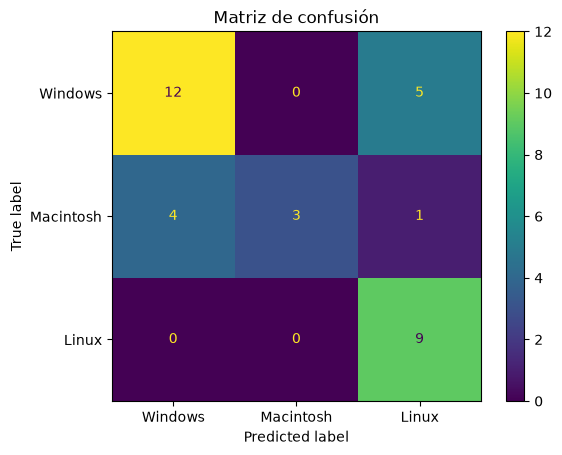

In [10]:

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Windows", "Macintosh", "Linux"]
)

disp.plot()
plt.title("Matriz de confusión")
plt.show()



## 8. Predecir el sistema operativo de un nuevo usuario

A continuación se carga un nuevo usuario con las cuatro características requeridas.

Se podrá modificar los valores para probar diferentes casos.


In [11]:

# Nuevo usuario:
# [duración en segundos, páginas vistas, acciones, valor de acciones]

nuevo_usuario = pd.DataFrame(
    [[120, 6, 15, 32]],
    columns=columnas_X
)

nuevo_usuario_scaled = scaler.transform(nuevo_usuario)

prediccion = modelo.predict(nuevo_usuario_scaled)[0]
probabilidades = modelo.predict_proba(nuevo_usuario_scaled)[0]

nombres_sistemas = {
    0: "Windows",
    1: "Macintosh",
    2: "Linux"
}

print("Características del nuevo usuario:")
display(nuevo_usuario)

print("Sistema operativo predicho:", nombres_sistemas[prediccion])

print("\nProbabilidades:")
for clase, prob in zip(modelo.classes_, probabilidades):
    print(f"{nombres_sistemas[clase]}: {prob:.2%}")


Características del nuevo usuario:


,duracion,paginas,acciones,valor
0,120,6,15,32


Sistema operativo predicho: Windows

Probabilidades:
Windows: 53.76%
Macintosh: 14.47%
Linux: 31.77%


## 9. Resultado obtenido

Con 80% de los datos para entrenamiento y 20% para prueba, usando `random_state=42` y estratificación:

- Registros totales: **170**
- Windows (0): **86**
- Macintosh (1): **40**
- Linux (2): **44**
- Exactitud (accuracy) sobre prueba: **70,59%**

La exactitud puede cambiar si se modifica la división de entrenamiento/prueba o los parámetros del modelo.
